In [1]:
import math
import numpy as np
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import poisson
from patsy import dmatrices
import statsmodels.graphics.tsaplots as tsa
from matplotlib import pyplot as plt
from statsmodels.tools.numdiff import approx_hess1, approx_hess2, approx_hess3
import scipy.optimize as opt
import pandas as pd

# GP1 HMM

In [2]:
def GP1_pmf(y, mu, alpha):
        if(alpha == 1 ):
                alpha == 0.9
        return ( 1/math.exp((mu + alpha*y) ) * mu * ( (mu + alpha*y)**(y-1) ) ) / (math.factorial(int(y)))

def GP1_mean(mu, alpha):
        if(alpha == 1 ):
                return ( mu ) / (0.9)
        else:
                return ( mu ) / (1-alpha)

def GP1_var(mu, alpha):
        if(alpha == 1 ):
                alpha == 0.9
        return ( mu ) / (1-alpha)**3

In [3]:
class GP1HMM(GenericLikelihoodModel):
    #endog:Yt; exog: X list of emission; k: #state; covariate:corvariate list of transtion matrix;
    #length: list of mutlti time serial data length, e.g. [15,22,30]; extra_params_names: name of parameters
    def __init__(self, endog, exog, k_regimes=2, covariate = None , length=None,loglike=None, score=None, hessian=None,
                 missing='none', extra_params_names=None, **kwds):
        super(GP1HMM, self).__init__(endog=endog, exog=exog, loglike=loglike, score=score,
                                         hessian=hessian, missing=missing,
                                         extra_params_names=extra_params_names, kwds=kwds)
        #Initialize all variable

        self.y = np.array(self.endog)
        self.k_regimes = k_regimes
        if covariate is not None:
            self.covariate = np.array(covariate)
        if length is not None:
            self.length = np.array(length)
        else:
            self.length = None
        
        # 1 x (k_regimes-1) proxy of initial state probability matrix
        self.initial_state_matrix = np.ones([1, self.k_regimes-1])/k_regimes

        #k_regimes x corvariate.shape[1] size matrix of regime specific self-recurrent regression coefficients
        self.covariate_beta_matrix = np.ones([self.k_regimes, self.covariate.shape[1] ])

        # k x (k-2) matrix of psuedo transition probabilities which can range from -inf to +inf during
        # optimization. Initialized to 1.0/k-2
        if self.k_regimes>2:
            self.q_matrix = np.ones([self.k_regimes,(self.k_regimes-2)])*(1.0/ (self.k_regimes-2) )

        #k_regimes x exog.shape[1] size matrix of regime specific regression coefficients
        self.beta_matrix = np.ones([self.k_regimes, self.exog.shape[1]])

        #The regime wise matrix of Poisson means. These would be updated during the optimization
        # loop
        self.mu_matrix = []

        #The GP2 dispersion parameter.
        self.alpha = np.zeros([self.k_regimes,1])

        # (t-1) x k x k matrix of the real Markov transition probabilities which will be calculated from
        # the q-matrix using a standardization technique. Initialized to 1.0/k
        self.gamma_matrix = np.ones([self.exog.shape[0]-1, self.k_regimes, self.k_regimes])*(1.0/self.k_regimes)

        # The Markov state probabilities. Also referred to as pi. but we'll use delta since pi is
        # often used to refer to the mean
        self.delta_matrix = np.ones([self.exog.shape[0],self.k_regimes])*(1.0/self.k_regimes)

        #A very tiny number (machine specific). Used by the LL function.
        self.EPS = np.MachAr().eps

        #Optimization iteration counter
        self.iter_num=0

        #The vector of initial values for all the parameters, beta and q, that the optimizer will
        # optimize
        self.start_params = self.beta_matrix.flatten()
        self.start_params = np.append(self.start_params, self.initial_state_matrix.flatten())
        self.start_params = np.append(self.start_params, self.covariate_beta_matrix.flatten())
        self.start_params = np.append(self.start_params, self.alpha.flatten())

        if k_regimes>2:
            self.start_params = np.append(self.start_params, self.q_matrix.flatten())

        self.ll_history = np.zeros([1,1])
        self.params_history = np.zeros([1,len(self.start_params)])
        self.MAE_history = np.zeros([1,1])

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeobs(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_poisson_means()

        # Compute the GP1 dispersion parameter
        #self.compute_GP1_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))))

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)

        #Return the negated array of  log-likelihood values
        return -ll

    #This method is called by the optimizer once in each iteration to get the current value of
    # the log-likelihood corresponding to the current values of all the parameters.
    def nloglikeopt(self, params):
        #Reconstitute the q and beta matrices from the current values of all the params
        self.reconstitute_parameter_matrices(params)

        #Build the regime wise matrix of Poisson means
        self.compute_regime_specific_poisson_means()

        # Compute the GP1 dispersion parameter
        #self.compute_GP1_alpha()

        #Build the matrix of Markov transition probabilities by standardizing all the q values to
        # the 0 to 1 range
        self.compute_markov_transition_probabilities()

        #Build the (len(y) x k) matrix delta of Markov state probabilities distribution. k state
        # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
        self.compute_markov_state_probabilities()

        #Let's increment the iteration count
        self.iter_num=self.iter_num+1

        # Compute all the log-likelihood values for the Poisson Markov model
        ll = self.compute_loglikelihood()

        #Sort beta_matrix, covariate_beta_matrix, delta_matrix, gamma_matrix and mu_matrix with k_state's emission intercept in ascending order 
        # using selection sort.
        self.sort()

        #Decode state path
        self.decode()
    
        #compute state specific MAE
        MAE = self.compute_mae()

        #Print out the iteration summary
        print('ITER='+str(self.iter_num) + ' ll='+str(((-ll).sum(0))) + ' MAE=' + str(MAE) )

        self.ll_history = np.append(self.ll_history, (ll.sum(0)).reshape([1,1]), axis=0)
        self.params_history = np.append(self.params_history, params.reshape([1,len(params)]), axis=0)
        self.MAE_history = np.append(self.MAE_history, np.array([MAE]).reshape([1,1]), axis = 0)


        #Return the negated array of  log-likelihood values
        return -ll.sum()

    # Reconstitute the q and beta matrices from the current values of all the params
    def reconstitute_parameter_matrices(self, params):
        index = 0

        self.beta_matrix = params[ : self.k_regimes*self.exog.shape[1] ]
        self.beta_matrix = self.beta_matrix.reshape([self.k_regimes, self.exog.shape[1] ]) 
        index = index + self.k_regimes*self.exog.shape[1]
        
        self.initial_state_matrix = params[index : index + self.k_regimes - 1 ]
        self.initial_state_matrix = self.initial_state_matrix.reshape([1, self.k_regimes-1])
        index = index + self.k_regimes - 1

        self.covariate_beta_matrix = params[index : index + self.k_regimes * self.covariate.shape[1]]
        self.covariate_beta_matrix = self.covariate_beta_matrix.reshape([self.k_regimes, self.covariate.shape[1] ])
        index = index + self.k_regimes * self.covariate.shape[1]
            
        if self.k_regimes>2:
            self.q_matrix = params[index : index + self.k_regimes*(self.k_regimes-2)]
            self.q_matrix = self.q_matrix.reshape([self.k_regimes, (self.k_regimes-2)])
            index = index + self.k_regimes * self.k_regimes
        
        self.alpha = params[index : index + self.k_regimes]
        self.alpha = self.alpha.reshape([self.k_regimes,1])

        


    # Build the regime wise matrix of Poisson means
    def compute_regime_specific_poisson_means(self):
        self.mu_matrix = []
        '''for k in range(1, self.k_regimes):
            self.beta_matrix[k][0] += np.exp(self.beta_matrix[k-1][0])'''

        for j in range(self.k_regimes):
            #Fetch the regression coefficients vector corresponding to the jth regime
            beta_j = self.beta_matrix[j]

            #Compute the Poisson mean and variance
            mu_j = np.exp(self.exog.dot(beta_j))
 

            if len(self.mu_matrix) == 0:
                self.mu_matrix = mu_j
            else:
                self.mu_matrix = np.vstack((self.mu_matrix,mu_j))


                
        self.mu_matrix = self.mu_matrix.transpose()
    
    # Compute the GP1 dispersion parameter
    def compute_GP1_alpha(self):

        N = len(self.y)*self.k_regimes
        k = self.beta_matrix.shape[1]
        sum = 0

        for i in range(self.k_regimes):
            for j in range(len(self.y)):
                sum += ( np.abs(self.y[j] - self.mu_matrix[j][i]) / ( (self.mu_matrix[j][i])**(1/2) ) - 1 )* (self.mu_matrix[j][i]**(-1))
            self.alpha[i] = sum / (N-k-1)


            
            if(self.alpha[i] <= (max(-1, -self.mu_matrix.max(axis=0)[i]/4 )) ):    
                self.alpha[i] = (max(-1, -self.mu_matrix.max(axis=0)[i]/4 )) + np.MachAr().eps
            elif(self.alpha[i] >= 1 ):
                self.alpha[i] = 1

    # Build the matrix of Markov transition probabilities by computing self-recurrent and non-recurrent state probabilities
    def compute_markov_transition_probabilities(self):
        
        # t x k recurrent matrix compute state k transition to itself in every time t
        self.recurrent_matrix = (self.covariate.dot(self.covariate_beta_matrix.transpose()))
        for t in range(self.exog.shape[0]-1):
            for i in range(self.k_regimes):
                for j in range(self.k_regimes):
                    if(i==j):
                        if(self.recurrent_matrix[t][j]>=709):
                            self.recurrent_matrix[t][j]=709
                        self.gamma_matrix[t][i][j] = math.exp(self.recurrent_matrix[t][j]) /( 1 + math.exp(self.recurrent_matrix[t][j]) )

        # If k=2, there's no need to use q_matrix
        if(self.k_regimes==2):
            for t in range(self.exog.shape[0]-1):
                for i in range(self.k_regimes):
                    for j in range(self.k_regimes):
                        if(i!=j):
                            self.gamma_matrix[t][i][j] = 1 - self.gamma_matrix[t][i][i]
        else:
            for t in range(self.exog.shape[0]-1):
                #Using  q to compute transtion probability which is not self-recurrent
                for i in range(self.k_regimes):
                    denom = 1
                    count = 0
                    for r in range(self.k_regimes-2):
                        denom += math.exp(self.q_matrix[i][r])
                        
                    for j in range(self.k_regimes):            
                        if(i==j ):continue
                        else:
                            if(count < self.k_regimes-2):
                                self.gamma_matrix[t][i][j] =( math.exp(self.q_matrix[i][count])/denom)*(1-self.gamma_matrix[t][i][i])
                                count+=1
                            else:
                                self.gamma_matrix[t][i][j] = (1.0/denom)*(1-self.gamma_matrix[t][i][i])

    # Build the (t x k) matrix delta of Markov state probabilities distribution. k state
    # probabilities corresponding to k regimes, times, number of time steps (i.e. observations)
    def compute_markov_state_probabilities(self):
        #Compute initial state probability
        denom = 1
        for r in range(self.k_regimes-1):
            if(self.initial_state_matrix[0][r]>709):
                self.initial_state_matrix[0][r] = 709
            denom += math.exp(self.initial_state_matrix[0][r])
            
        for j in range(self.k_regimes-1):
            self.delta_matrix[0][j] = math.exp(self.initial_state_matrix[0][j])/denom
        self.delta_matrix[0][self.k_regimes-1] = 1.0/denom

        #Compute state probabilties in each time t seperately if there's multiple time serial data.
        if(self.length is not None):
            index = 1
            for n in range(len(self.length)):
                for t in range(index, index + self.length[n] - 1):
                    self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])
                index += self.length[n]
                if (index-1) < len(self.y):
                    self.delta_matrix[index-1]= self.delta_matrix[0]
        else:
            for t in range(1, len(self.y)):
                self.delta_matrix[t] = np.matmul(self.delta_matrix[t-1], self.gamma_matrix[t-1])


    # Compute all the log-likelihood values for the Poisson Markov model
    def compute_loglikelihood(self):
        #Init the list of loglikelihhod values, one value for each y observation
        ll = []
        for t in range(len(self.y)):
            prob_y_t = 0
            mu_t = 0
            for j in range(self.k_regimes):
                #To use the law of total probability, uncomment this row and comment out the next
                # two rows

                prob_y_t += GP1_pmf(self.y[t], GP1_mean(self.mu_matrix[t][j], self.alpha[j]) , self.alpha[j] ) * self.delta_matrix[t][j]
                #Calculate the Poisson mean mu_t as an expectation over all Markov state
                # probabilities
                #mu_t += self.mu_matrix[t][j] * self.delta_matrix[t][j]
                #prob_y_t += poisson.pmf(self.y[t], mu_t)

            #This is a bit of a kludge. If the likelihood turns out to be real tiny, fix it to
            # the EPS value for the machine
            if prob_y_t < self.EPS:
                prob_y_t = self.EPS
            #Push the LL into the list of LLs
            ll.append(math.log(prob_y_t))
        ll = np.array(ll)
        return ll
    
    #Decode state path
    def decode(self):
        #decoded state path matrix: t
        self.decode_matrix = np.ones([len(self.y)])
        self.state_specific_mu = np.zeros([len(self.y),1])
        
        for t in range( len(self.y) ):
            max = 0
            state = 0
            for k in range(self.k_regimes):
                if(k == 0):
                    max = self.delta_matrix[t][k]
                    state = state + 1
                else:
                    if(self.delta_matrix[t][k] > max):
                        state = state + 1
                        max = self.delta_matrix[t][k]
            self.decode_matrix[t] = state

        #compute state specific mu
        for t in range( len(self.y) ):
            for k in range(1,self.k_regimes+1):
                if (self.decode_matrix[t] == k):
                    self.state_specific_mu[t] = self.mu_matrix[t][k-1]/(1-self.alpha[k-1])
    
    #compute state specific MAE
    def compute_mae(self):
        return ((np.abs(self.state_specific_mu.reshape([len(self.y),])-self.y)).mean())


    #Sort beta_matrix, covariate_beta_matrix, delta_matrix, gamma_matrix and mu_matrix with k_state's emission intercept in ascending order 
    # using selection sort.
    def sort(self):
        for i in range(self.k_regimes-1):
            minimum = i
            for j in range(i+1,self.k_regimes):
                if( self.beta_matrix[minimum][0] > self.beta_matrix[j][0] ):
                    minimum = j
            if(minimum != i):
                self.beta_matrix = list(self.beta_matrix)
                self.beta_matrix[minimum], self.beta_matrix[i] =  self.beta_matrix[i], self.beta_matrix[minimum]
                self.beta_matrix = np.array(self.beta_matrix)

                self.covariate_beta_matrix = list(self.covariate_beta_matrix)
                self.covariate_beta_matrix[minimum], self.covariate_beta_matrix[i] = self.covariate_beta_matrix[i], self.covariate_beta_matrix[minimum]
                self.covariate_beta_matrix = np.array(self.covariate_beta_matrix)

                self.delta_matrix = list(self.delta_matrix)
                self.mu_matrix = list(self.mu_matrix)

                for t in range(len(self.y)):
                    self.delta_matrix[t][minimum], self.delta_matrix[t][i] =  self.delta_matrix[t][i], self.delta_matrix[t][minimum]
                    self.mu_matrix[t][minimum], self.mu_matrix[t][i] =  self.mu_matrix[t][i], self.mu_matrix[t][minimum]
                self.delta_matrix = np.array(self.delta_matrix)
                self.mu_matrix = np.array(self.mu_matrix)

                self.gamma_matrix = list(self.gamma_matrix) 
                for t in range(len(self.y)-1):
                    self.gamma_matrix[t][minimum][minimum], self.gamma_matrix[t][i][i] = self.gamma_matrix[t][i][i], self.gamma_matrix[t][minimum][minimum]
                    self.gamma_matrix[t][minimum][i], self.gamma_matrix[t][i][minimum] = self.gamma_matrix[t][i][minimum], self.gamma_matrix[t][minimum][i]
                self.gamma_matrix = np.array(self.gamma_matrix)

# Data Cleaning

**10 Assortments Data Cleaning**

In [4]:
assortment_1_data = pd.read_csv(r'dayRecord1_103665.csv')
assortment_2_data = pd.read_csv(r'dayRecord1_108696.csv')
assortment_3_data = pd.read_csv(r'dayRecord1_108698.csv')
assortment_4_data = pd.read_csv(r'dayRecord1_108701.csv')
assortment_5_data = pd.read_csv(r'dayRecord1_153395.csv')
assortment_6_data = pd.read_csv(r'dayRecord1_122095.csv')
assortment_7_data = pd.read_csv(r'dayRecord1_123347.csv')
assortment_8_data = pd.read_csv(r'dayRecord1_127547.csv')
assortment_9_data = pd.read_csv(r'dayRecord1_129635.csv')
assortment_10_data = pd.read_csv(r'dayRecord1_153398.csv')

In [5]:
assortment_1_data = assortment_1_data.dropna()
assortment_2_data = assortment_2_data.dropna()
assortment_3_data = assortment_3_data.dropna()
assortment_4_data = assortment_4_data.dropna()
assortment_5_data = assortment_5_data.dropna()
assortment_6_data = assortment_6_data.dropna()
assortment_7_data = assortment_7_data.dropna()
assortment_8_data = assortment_8_data.dropna()
assortment_9_data = assortment_9_data.dropna()
assortment_10_data = assortment_10_data.dropna()

In [6]:
assortment_1_data.index = range(len(assortment_1_data))
assortment_2_data.index = range(len(assortment_2_data))
assortment_3_data.index = range(len(assortment_3_data))
assortment_4_data.index = range(len(assortment_4_data))
assortment_5_data.index = range(len(assortment_5_data))
assortment_6_data.index = range(len(assortment_6_data))
assortment_7_data.index = range(len(assortment_7_data))
assortment_8_data.index = range(len(assortment_8_data))
assortment_9_data.index = range(len(assortment_9_data))
assortment_10_data.index = range(len(assortment_10_data))


**10 assortments unit sales in 100 days as training data**

In [7]:
assortment_train_data = assortment_1_data[:200]
assortment_train_data = assortment_train_data.append(assortment_2_data[:200])
assortment_train_data = assortment_train_data.append(assortment_3_data[:200])
assortment_train_data = assortment_train_data.append(assortment_4_data[:200])
assortment_train_data = assortment_train_data.append(assortment_5_data[:200])
assortment_train_data = assortment_train_data.append(assortment_6_data[:200])
assortment_train_data = assortment_train_data.append(assortment_7_data[:200])
assortment_train_data = assortment_train_data.append(assortment_8_data[:200])
assortment_train_data = assortment_train_data.append(assortment_9_data[:200])
assortment_train_data = assortment_train_data.append(assortment_10_data[:200])

C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\2470582077.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assortment_train_data = assortment_train_data.append(assortment_2_data[:200])
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\2470582077.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assortment_train_data = assortment_train_data.append(assortment_3_data[:200])
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\2470582077.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assortment_train_data = assortment_train_data.append(assortment_4_data[:200])
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\2470582077.py:5: FutureWarning: The frame.append method is deprecated and will be removed from pandas 

**10 assortments unit sales in 50 days after 100 days as testing data**

In [8]:
assortment_test_data = assortment_1_data[200:400]
assortment_test_data = assortment_test_data.append(assortment_2_data[200:400])
assortment_test_data = assortment_test_data.append(assortment_3_data[200:400])
assortment_test_data = assortment_test_data.append(assortment_4_data[200:400])
assortment_test_data = assortment_test_data.append(assortment_5_data[200:400])
assortment_test_data = assortment_test_data.append(assortment_6_data[200:400])
assortment_test_data = assortment_test_data.append(assortment_7_data[200:400])
assortment_test_data = assortment_test_data.append(assortment_8_data[200:400])
assortment_test_data = assortment_test_data.append(assortment_9_data[200:400])
assortment_test_data = assortment_test_data.append(assortment_10_data[200:400])

C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\1394454823.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assortment_test_data = assortment_test_data.append(assortment_2_data[200:400])
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\1394454823.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assortment_test_data = assortment_test_data.append(assortment_3_data[200:400])
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\1394454823.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  assortment_test_data = assortment_test_data.append(assortment_4_data[200:400])
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\1394454823.py:5: FutureWarning: The frame.append method is deprecated and will be removed from pand

In [9]:
assortment_train_data

,date,item_nbr,unit_sales,onpromotion,weekday,DayFromWagePaid,DayToWagePaid,OilPrice,transactions,type
0,2014/4/1,103665.0,3.0,False,1,1,14,99.690000,1847.0,Work
1,2014/4/2,103665.0,2.0,False,2,2,13,99.600000,1899.0,Work
2,2014/4/3,103665.0,1.0,False,3,3,12,100.290000,1789.0,Work
3,2014/4/4,103665.0,2.0,False,4,4,11,101.160000,1875.0,Work
4,2014/4/5,103665.0,8.0,False,5,5,10,100.916667,1393.0,Weekend
...,...,...,...,...,...,...,...,...,...,...
195,2014-11-10,153398.0,2.0,False,0,10,5,77.430000,1713.0,Work
196,2014-11-11,153398.0,3.0,False,1,11,4,77.850000,1703.0,Work
197,2014-11-12,153398.0,6.0,False,2,12,3,77.160000,1882.0,Work
198,2014-11-13,153398.0,6.0,False,3,13,2,74.130000,1692.0,Work


In [10]:
assortment_test_data

,date,item_nbr,unit_sales,onpromotion,weekday,DayFromWagePaid,DayToWagePaid,OilPrice,transactions,type
200,2014/11/27,103665.0,2.0,False,3,12,3,69.820000,1713.0,Work
201,2014/11/29,103665.0,4.0,False,5,14,1,66.953333,1304.0,Weekend
202,2014/11/30,103665.0,4.0,False,6,0,0,67.966667,540.0,Weekend
203,2014/12/1,103665.0,1.0,False,0,1,14,68.980000,1953.0,Holiday
204,2014/12/2,103665.0,1.0,False,1,2,13,66.990000,1819.0,Work
...,...,...,...,...,...,...,...,...,...,...
395,2015-06-10,153398.0,10.0,False,2,10,5,61.360000,1852.0,Work
396,2015-06-11,153398.0,3.0,False,3,11,4,60.740000,1789.0,Work
397,2015-06-12,153398.0,4.0,False,4,12,3,59.960000,1849.0,Work
398,2015-06-13,153398.0,7.0,False,5,13,2,59.816667,1282.0,Weekend


In [11]:
for i in range(1,11):
    assortment_train_data['assortment_'+str(i)] = 0
    assortment_train_data['assortment_'+str(i)][100*(i-1):100*i] = 1
    

C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\1106701903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assortment_train_data['assortment_'+str(i)][100*(i-1):100*i] = 1
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\1106701903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assortment_train_data['assortment_'+str(i)][100*(i-1):100*i] = 1
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\1106701903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

In [12]:
for i in range(1,11):
    assortment_test_data['assortment_'+str(i)] = 0
    assortment_test_data['assortment_'+str(i)][50*(i-1):50*i] = 1

C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\3810075648.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assortment_test_data['assortment_'+str(i)][50*(i-1):50*i] = 1
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\3810075648.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assortment_test_data['assortment_'+str(i)][50*(i-1):50*i] = 1
C:\Users\M07273\AppData\Local\Temp\ipykernel_121004\3810075648.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

In [13]:
assortment_train_data['unit_sales_lag1'] = assortment_train_data['unit_sales'].shift(1)
assortment_test_data['unit_sales_lag1'] = assortment_test_data['unit_sales'].shift(1)

In [14]:
def indicator_func(x):
    if x == 0:
        return 1
    else:
        return 0

def onpromotion_func(x):
    if x :
        return 1
    else:
        return 0

def is_work_func(x):
    if x == 'Work':
        return 1
    else:
        return 0

def is_weekend_func(x):
    if x == 'Weekend':
        return 1
    else:
        return 0

def is_holiday_func(x):
    if x == 'Holiday':
        return 1
    else:
        return 0

def is_Sunday_func(x):
    if x == 0:
        return 1
    else:
        return 0

def is_Monday_func(x):
    if x == 1:
        return 1
    else:
        return 0

def is_Tuesday_func(x):
    if x == 2:
        return 1
    else:
        return 0

def is_Wednseday_func(x):
    if x == 3:
        return 1
    else:
        return 0

def is_Thursday_func(x):
    if x == 4:
        return 1
    else:
        return 0

def is_Friday_func(x):
    if x == 5:
        return 1
    else:
        return 0

def is_Saturday_func(x):
    if x == 6:
        return 1
    else:
        return 0

In [15]:
assortment_train_data['d1'] = assortment_train_data['unit_sales_lag1'].apply(indicator_func)
assortment_train_data['unit_sales_lag1']=np.maximum(1,assortment_train_data['unit_sales_lag1'])
assortment_train_data['ln_unit_sales_lag1']=np.log(assortment_train_data['unit_sales_lag1'])
assortment_train_data['OilPrice'] = (assortment_train_data['OilPrice']- assortment_train_data['OilPrice'].mean())/ assortment_train_data['OilPrice'].std()
assortment_train_data['transactions'] = (assortment_train_data['transactions']- assortment_train_data['transactions'].mean())/ assortment_train_data['transactions'].std()

In [16]:
assortment_test_data['d1'] = assortment_test_data['unit_sales_lag1'].apply(indicator_func)
assortment_test_data['unit_sales_lag1']=np.maximum(1,assortment_test_data['unit_sales_lag1'])
assortment_test_data['ln_unit_sales_lag1']=np.log(assortment_test_data['unit_sales_lag1'])
assortment_test_data['OilPrice'] = (assortment_test_data['OilPrice']- assortment_test_data['OilPrice'].mean())/ assortment_test_data['OilPrice'].std()
assortment_test_data['transactions'] = (assortment_test_data['transactions']- assortment_test_data['transactions'].mean())/ assortment_test_data['transactions'].std()

In [17]:
assortment_train_data['onpromotion'] = assortment_train_data['onpromotion'].apply(onpromotion_func)
assortment_train_data['work'] = assortment_train_data['type'].apply(is_work_func)
assortment_train_data['weekend'] = assortment_train_data['type'].apply(is_weekend_func)
assortment_train_data['holiday'] = assortment_train_data['type'].apply(is_holiday_func)

In [18]:
assortment_test_data['onpromotion'] = assortment_test_data['onpromotion'].apply(onpromotion_func)
assortment_test_data['work'] = assortment_test_data['type'].apply(is_work_func)
assortment_test_data['weekend'] = assortment_test_data['type'].apply(is_weekend_func)
assortment_test_data['holiday'] = assortment_test_data['type'].apply(is_holiday_func)

In [19]:
assortment_train_data['Sun'] = assortment_train_data['weekday'].apply(is_Sunday_func)
assortment_train_data['Mon'] = assortment_train_data['weekday'].apply(is_Monday_func)
assortment_train_data['Tue'] = assortment_train_data['weekday'].apply(is_Tuesday_func)
assortment_train_data['Wed'] = assortment_train_data['weekday'].apply(is_Wednseday_func)
assortment_train_data['Thu'] = assortment_train_data['weekday'].apply(is_Thursday_func)
assortment_train_data['Fri'] = assortment_train_data['weekday'].apply(is_Friday_func)
assortment_train_data['Sat'] = assortment_train_data['weekday'].apply(is_Saturday_func)

In [20]:
assortment_test_data['Sun'] = assortment_test_data['weekday'].apply(is_Sunday_func)
assortment_test_data['Mon'] = assortment_test_data['weekday'].apply(is_Monday_func)
assortment_test_data['Tue'] = assortment_test_data['weekday'].apply(is_Tuesday_func)
assortment_test_data['Wed'] = assortment_test_data['weekday'].apply(is_Wednseday_func)
assortment_test_data['Thu'] = assortment_test_data['weekday'].apply(is_Thursday_func)
assortment_test_data['Fri'] = assortment_test_data['weekday'].apply(is_Friday_func)
assortment_test_data['Sat'] = assortment_test_data['weekday'].apply(is_Saturday_func)

In [21]:
#assortment_train_data.to_csv('assortment_train_data.csv')
#assortment_test_data.to_csv('assortment_test_data.csv')

In [22]:
expr = 'unit_sales ~ ln_unit_sales_lag1 + assortment_1 + assortment_2 \
      + assortment_3 + assortment_4 + assortment_5 + assortment_6 + assortment_7 + assortment_8 + assortment_9 + assortment_10  '
y_train, x_train = dmatrices(expr, assortment_train_data, return_type='dataframe')

In [23]:
x_train

,Intercept,ln_unit_sales_lag1,assortment_1,assortment_2,assortment_3,assortment_4,assortment_5,assortment_6,assortment_7,assortment_8,assortment_9,assortment_10
1,1.0,1.098612,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.693147,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.693147,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.0,2.079442,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.0,1.791759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196,1.0,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
197,1.0,1.098612,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
198,1.0,1.791759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
print(y_train)

     unit_sales
1           2.0
2           1.0
3           2.0
4           8.0
5           3.0
..          ...
195         2.0
196         3.0
197         6.0
198         6.0
199         7.0

[1999 rows x 1 columns]


In [25]:
x_train.to_csv("x_train.csv")

# Training GP1 regression model and GP1 HMM

**Conduct GP1 regression**

In [26]:
gen_poisson_gp1 = sm.GeneralizedPoisson(y_train, x_train, p=1)
gen_poisson_gp1_results = gen_poisson_gp1.fit()

Optimization terminated successfully.
         Current function value: 2.175452
         Iterations: 23
         Function evaluations: 26
         Gradient evaluations: 26


**AIC**

In [27]:
print(gen_poisson_gp1_results.summary())

                    GeneralizedPoisson Regression Results                     
Dep. Variable:             unit_sales   No. Observations:                 1999
Model:             GeneralizedPoisson   Df Residuals:                     1987
Method:                           MLE   Df Model:                           11
Date:                Tue, 12 Jul 2022   Pseudo R-squ.:                 0.07070
Time:                        15:07:29   Log-Likelihood:                -4348.7
converged:                       True   LL-Null:                       -4679.6
Covariance Type:            nonrobust   LLR p-value:                8.853e-135
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.0569      0.036     29.097      0.000       0.986       1.128
ln_unit_sales_lag1     0.3840      0.021     18.649      0.000       0.344       0.424
assortment_1        

In [28]:
gen_poisson_gp1_results.aic

8723.457960899428

In [29]:
gp1_regression_prediction = np.exp(x_train.dot(gen_poisson_gp1_results.params[:-1]))

In [30]:
(y_train)

,unit_sales
1,2.0
2,1.0
3,2.0
4,8.0
5,3.0
...,...
195,2.0
196,3.0
197,6.0
198,6.0


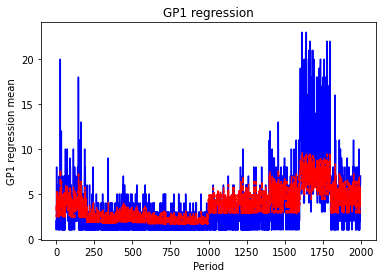

In [31]:
#Plot the number of unit sales in each period
y = y_train['unit_sales']
plt.xlabel('Period')
plt.ylabel('Unit sales')
plt.plot(range(len(y)),y,'-b')

plt.xlabel('Period')
plt.ylabel('GP1 regression mean')
plt.title("GP1 regression")
plt.plot(range(len(gp1_regression_prediction)),gp1_regression_prediction,'--r')

plt.show()

**MAE**

In [32]:
np.abs(gp1_regression_prediction - y).mean()


2.028518703269197

**Conduct GP1 HMM with covariate training**

In [33]:
cor = 'unit_sales ~ DayToWagePaid'
y, covariate = dmatrices(cor, assortment_train_data, return_type='dataframe')
#del covariate['DayToWagePaid']

In [34]:
length = np.array([199, 200, 200, 200, 200, 200, 200, 200, 200, 200])

In [35]:
k_regimes = 2
extra_params_names = []

for regime_num in range(1, k_regimes):
    for param_name in x_train.columns:
        extra_params_names.append(param_name+'_R'+str(regime_num))

for k in range(k_regimes-1):
    extra_params_names.append('Initial state_'+str(k))

for regime_num in range(k_regimes):
#    extra_params_names.append("Intercept_"+str(regime_num))
    for param_name in covariate.columns:
        extra_params_names.append(param_name+"_"+str(regime_num))
    

#for i in range(k_regimes):
#    for j in range(k_regimes-2):
#        extra_params_names.append('q_'+str(i)+str(j))

for k in range(k_regimes):
    extra_params_names.append('alpha '+ str(k))

In [36]:
gp1_hmm = GP1HMM(endog=y_train, exog=x_train, covariate=covariate,
                        k_regimes=k_regimes,length=length,
                        extra_params_names=extra_params_names)

params = gp1_hmm.start_params
params[:-2] = params[:-2] /1000


In [37]:
gp1_hmm.start_params.shape[0]
const1 = np.zeros([gp1_hmm.start_params.shape[0]])
const1[-2:] = 1
const1[-1] = 0

const2 = np.zeros([gp1_hmm.start_params.shape[0]])
const2[-1] = 1


In [38]:
constraint1 = opt.LinearConstraint(list(const1), 0, 1)
constraint2 = opt.LinearConstraint(list(const2), 0, 1)

In [39]:
res=opt.minimize(gp1_hmm.nloglikeopt,params, method='Nelder-Mead',constraints = (constraint1, constraint2))

#gp1_hmm_results = gp1_hmm.fit(method='bfgs', maxiter=400)

c:\Users\M07273\Anaconda3\lib\site-packages\scipy\optimize\_minimize.py:541: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  warn('Method %s cannot handle constraints.' % method,


ITER=1 ll=9800.243419609174 MAE=2.7597376268850273
ITER=2 ll=9800.117932300254 MAE=2.759734268247209
ITER=3 ll=9800.062581639339 MAE=2.7597079396911757
ITER=4 ll=9800.236476974826 MAE=2.759736045984669
ITER=5 ll=9800.236752019504 MAE=2.759736071084413
ITER=6 ll=9800.240201204582 MAE=2.7597368244104032
ITER=7 ll=9800.240950944992 MAE=2.759737476613112
ITER=8 ll=9800.240026284731 MAE=2.759736724063648
ITER=9 ll=9800.24055111461 MAE=2.75973707519766
ITER=10 ll=9800.241250850202 MAE=2.7597375266348805
ITER=11 ll=9800.241475699182 MAE=2.7597378275802957
ITER=12 ll=9800.241575669614 MAE=2.7597378776361063
ITER=13 ll=9800.241650656688 MAE=2.7597377272434995
ITER=14 ll=9800.117932726655 MAE=2.7597376268850273
ITER=15 ll=9800.062582094595 MAE=2.7597376268850273
ITER=16 ll=9800.236476987287 MAE=2.7597376268850273
ITER=17 ll=9800.236752019504 MAE=2.7597376268850273
ITER=18 ll=9800.240201204557 MAE=2.7597376268850273
ITER=19 ll=9800.240950944992 MAE=2.7597376268850273
ITER=20 ll=9800.240026297532 

In [40]:
for i in range(4):
    res=opt.minimize(gp1_hmm.nloglikeopt,res.x, method='Nelder-Mead')

ITER=6201 ll=4447.045067118625 MAE=2.2867597219306672
ITER=6202 ll=4446.817692761152 MAE=2.2866792297408725
ITER=6203 ll=4447.712798673649 MAE=2.28696158505259
ITER=6204 ll=4447.060822474613 MAE=2.286762692394913
ITER=6205 ll=4447.046061886296 MAE=2.286759980105433
ITER=6206 ll=4447.04394695137 MAE=2.286759153111272
ITER=6207 ll=4447.014590686107 MAE=2.2867623055009254
ITER=6208 ll=4447.060776012909 MAE=2.286751077022512
ITER=6209 ll=4447.0531217500975 MAE=2.2867674082656566
ITER=6210 ll=4447.037129591015 MAE=2.2867630710122993
ITER=6211 ll=4447.108271086365 MAE=2.286823470114644
ITER=6212 ll=4447.049757208721 MAE=2.2867606093303228
ITER=6213 ll=4447.001621912295 MAE=2.2867457961086344
ITER=6214 ll=4446.911357767848 MAE=2.2890041707758235
ITER=6215 ll=4451.045439371708 MAE=2.371603338624925
ITER=6216 ll=4447.134715728859 MAE=2.2874918190560343
ITER=6217 ll=4447.070605875727 MAE=2.2869849094635164
ITER=6218 ll=4447.055419067871 MAE=2.2862775586919355
ITER=6219 ll=4447.265473284039 MAE=2

In [41]:
print(res)

 final_simplex: (array([[ 1.46251368e+00,  2.52838459e-02,  1.34530850e-01,
         1.24511033e-03, -2.78315120e-01, -4.09637417e-01,
        -2.15304361e-01, -2.50124146e-01, -3.38181661e-01,
        -4.81347219e-01, -5.14680739e-01, -4.55306989e-01,
         8.85067576e-01,  3.76429388e-01, -1.80931265e-01,
        -2.33673106e-01, -5.79791462e-01, -6.20856163e-01,
        -5.90137618e-01, -6.44663844e-01, -7.76358733e-01,
        -7.51018689e-01, -7.50364921e-01, -7.96820166e-01,
        -1.85577359e-01, -8.00528715e+00,  5.26460257e+00,
        -1.68274386e+01,  1.26565008e+01, -3.64118343e-01,
         2.21478541e-01],
       [ 1.46262057e+00,  2.53144690e-02,  1.34851780e-01,
         1.23070700e-03, -2.78066678e-01, -4.09855422e-01,
        -2.15492697e-01, -2.50321821e-01, -3.38124991e-01,
        -4.81070229e-01, -5.14789589e-01, -4.55666132e-01,
         8.85111372e-01,  3.76434806e-01, -1.80978986e-01,
        -2.33740229e-01, -5.80246796e-01, -6.20810017e-01,
        -5.89

In [42]:
res.x

array([ 1.46251368e+00,  2.52838459e-02,  1.34530850e-01,  1.24511033e-03,
       -2.78315120e-01, -4.09637417e-01, -2.15304361e-01, -2.50124146e-01,
       -3.38181661e-01, -4.81347219e-01, -5.14680739e-01, -4.55306989e-01,
        8.85067576e-01,  3.76429388e-01, -1.80931265e-01, -2.33673106e-01,
       -5.79791462e-01, -6.20856163e-01, -5.90137618e-01, -6.44663844e-01,
       -7.76358733e-01, -7.51018689e-01, -7.50364921e-01, -7.96820166e-01,
       -1.85577359e-01, -8.00528715e+00,  5.26460257e+00, -1.68274386e+01,
        1.26565008e+01, -3.64118343e-01,  2.21478541e-01])

In [43]:
gp1_hmm.sort()
'''(gp1_hmm_results.params = gp1_hmm.beta_matrix.flatten()
gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.initial_state_matrix.flatten())
gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.covariate_beta_matrix.flatten())
if k_regimes>2:
    gp1_hmm_results.params = np.append(gp1_hmm_results.params, gp1_hmm.q_matrix.flatten()))'''
    
print('Mean of transition matrix:')
print(np.mean(gp1_hmm.gamma_matrix,axis = 0))

Mean of transition matrix:
[[0.87286081 0.12713919]
 [0.12900982 0.87099018]]


**Emission**

In [44]:
for k in range(k_regimes):
    for i  in range(gp1_hmm.beta_matrix.shape[1]):
        print(x_train.columns[i],str(k + 1)+':',np.round(gp1_hmm.beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: 0.89. ln_unit_sales_lag1 1: 0.38. assortment_1 1: -0.18. assortment_2 1: -0.23. assortment_3 1: -0.58. assortment_4 1: -0.62. assortment_5 1: -0.59. assortment_6 1: -0.65. assortment_7 1: -0.78. assortment_8 1: -0.75. assortment_9 1: -0.75. assortment_10 1: -0.8. 
Intercept 2: 1.46. ln_unit_sales_lag1 2: 0.03. assortment_1 2: 0.13. assortment_2 2: 0.0. assortment_3 2: -0.28. assortment_4 2: -0.41. assortment_5 2: -0.22. assortment_6 2: -0.25. assortment_7 2: -0.34. assortment_8 2: -0.48. assortment_9 2: -0.51. assortment_10 2: -0.46. 


**Transition Matrix**

In [45]:
for k in range(k_regimes):
    for i  in range(gp1_hmm.covariate_beta_matrix.shape[1]):
        print(covariate.columns[i],str(k + 1)+':',np.round(gp1_hmm.covariate_beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: -16.81. DayToWagePaid 1: 12.64. 
Intercept 2: -8.01. DayToWagePaid 2: 5.27. 


In [46]:
gp1_hmm.decode()

In [47]:
state_specific_mu = np.zeros([y_train.shape[0]])
for t in range(y_train.shape[0]):
    if (gp1_hmm.decode_matrix[t] == 1):
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][0]/(1-gp1_hmm.alpha[0])
    elif(gp1_hmm.decode_matrix[t] == 2):
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][1]/(1-gp1_hmm.alpha[1])
    else:
        state_specific_mu[t] = gp1_hmm.mu_matrix[t][2]/(1-gp1_hmm.alpha[2])

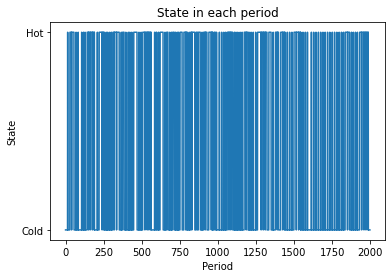

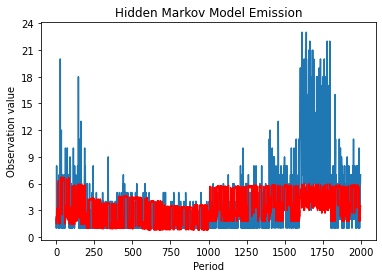

In [48]:
from matplotlib.ticker import MaxNLocator

#Plot the state each month
plt.xlabel('Period')
plt.ylabel('State')
plt.title("State in each period")
plt.yticks([1,2],['Cold','Hot'])
plt.plot(range(y_train.shape[0]),gp1_hmm.decode_matrix)
plt.show()

#Plot the number of strikes starting each month
plt.xlabel('Period')
plt.ylabel('Observation value')
plt.title("Hidden Markov Model Emission")
plt.plot(range(y_train.shape[0]),assortment_train_data['unit_sales'][1:])
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

#Plot the mu_2 each month
plt.plot(range(y_train.shape[0]),gp1_hmm.state_specific_mu,'-r')

plt.show()

**MAE**

In [49]:
np.abs(state_specific_mu-assortment_train_data['unit_sales'][1:]).mean()

2.522714290537949

**AIC**

In [50]:
int((-(gp1_hmm.ll_history[-1])*2+gp1_hmm.start_params.shape[0]*2))

8319

In [51]:
gp1_hmm.alpha

array([[-0.36411518],
       [ 0.22149384]])

# Testing data performance

**Test data evaluation**

In [52]:
y_train, x_train = dmatrices(expr, assortment_train_data, return_type='dataframe')
y_test, x_test = dmatrices(expr, assortment_test_data, return_type='dataframe')

In [53]:
length_test = [199, 200, 200, 200, 200, 200, 200, 200, 200, 200]

### GP1 regression models in testing data performance

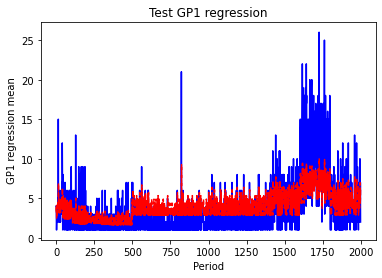

In [92]:
test_gp1_regression_prediction = np.exp(x_test.dot(gen_poisson_gp1_results.params[:-1]))
y_test_set = y_test['unit_sales']
#Plot the number of unit sales in each period
plt.xlabel('Period')
plt.ylabel('Unit sales')
plt.plot(range(len(y_test_set)),y_test_set,'-b')

plt.xlabel('Period')
plt.ylabel(' GP1 regression mean')
plt.title("Test GP1 regression")
plt.plot(range(len(test_gp1_regression_prediction)),test_gp1_regression_prediction,'--r')

plt.show()

**MAE**

In [55]:
np.abs(test_gp1_regression_prediction - assortment_test_data['unit_sales'][1:]).mean()


2.1663287802981674

**LL**

In [56]:
gen_poisson_gp1_test = sm.GeneralizedPoisson(y_test, x_test, p=1)
gen_poisson_gp1_test.loglikeobs(gen_poisson_gp1_results.params).sum()


-4413.260689817047

**AIC**

In [76]:
gen_poisson_gp1_test.loglikeobs(gen_poisson_gp1_results.params).sum()*(-2) + gen_poisson_gp1_results.params.shape[0]*2

8852.521379634094

### GP1 HMM in testing data performance

In [57]:
y, covariate_test = dmatrices(cor, assortment_test_data, return_type='dataframe')
#del covariate['DayToWagePaid']

In [58]:
gp1_hmm_test = GP1HMM(endog=y_test, exog=x_test, covariate=covariate_test,
                        k_regimes=k_regimes,length = length_test,
                        extra_params_names=extra_params_names)


**LL and MAE**

In [84]:
params = gp1_hmm.params_history[7035]
gp1_hmm_test.nloglikeopt(params)

ITER=6 ll=4383.785179083844 MAE=1.9875398279232794


4383.785179083844

In [85]:
gp1_hmm_test.nloglikeopt(params)*2 + params.shape[0]*2

ITER=7 ll=4383.785179083844 MAE=1.9875398279232794


8829.570358167688

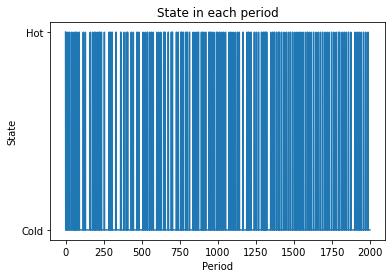

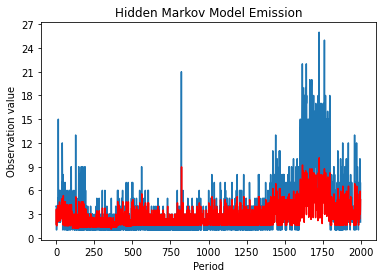

In [86]:
from matplotlib.ticker import MaxNLocator

#Plot the state each month
plt.xlabel('Period')
plt.ylabel('State')
plt.title("State in each period")
plt.yticks([1,2],['Cold','Hot'])
plt.plot(range(y_test.shape[0]),gp1_hmm_test.decode_matrix)
plt.show()

#Plot the number of strikes starting each month
plt.xlabel('Period')
plt.ylabel('Observation value')
plt.title("Hidden Markov Model Emission")
plt.plot(range(y_test.shape[0]),assortment_test_data['unit_sales'][1:])
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

#Plot the mu_2 each month
plt.plot(range(y_test.shape[0]),gp1_hmm_test.state_specific_mu,'-r')

plt.show()

### **Training set performance (Iter = 8000)**

In [87]:
gp1_hmm_train = GP1HMM(endog=y_train, exog=x_train, covariate=covariate,
                        k_regimes=k_regimes,length=length,
                        extra_params_names=extra_params_names)


gp1_hmm_train.nloglikeopt(params)

ITER=1 ll=4402.703218364716 MAE=2.0152441017995195


4402.703218364716

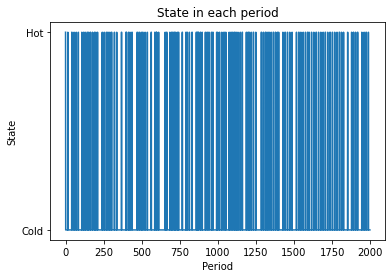

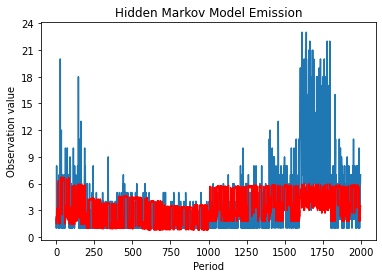

In [88]:
from matplotlib.ticker import MaxNLocator

#Plot the state each month
plt.xlabel('Period')
plt.ylabel('State')
plt.title("State in each period")
plt.yticks([1,2],['Cold','Hot'])
plt.plot(range(y_train.shape[0]),gp1_hmm_train.decode_matrix)
plt.show()

#Plot the number of strikes starting each month
plt.xlabel('Period')
plt.ylabel('Observation value')
plt.title("Hidden Markov Model Emission")
plt.plot(range(y_train.shape[0]),assortment_train_data['unit_sales'][1:])
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

#Plot the mu_2 each month
plt.plot(range(y_train.shape[0]),gp1_hmm.state_specific_mu,'-r')

plt.show()

**AIC**

In [89]:
params.shape[0]*2+gp1_hmm_train.nloglikeopt(params)*2

ITER=2 ll=4402.703218364716 MAE=2.0152441017995195


8867.406436729432

**Emission**

In [93]:
for k in range(k_regimes):
    for i  in range(gp1_hmm_train.beta_matrix.shape[1]):
        print(x_train.columns[i],str(k + 1)+':',np.round(gp1_hmm_train.beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: 0.07. ln_unit_sales_lag1 1: 0.56. assortment_1 1: 0.03. assortment_2 1: -0.05. assortment_3 1: -0.28. assortment_4 1: -0.2. assortment_5 1: -0.15. assortment_6 1: -0.15. assortment_7 1: -0.16. assortment_8 1: -0.16. assortment_9 1: 0.04. assortment_10 1: -0.06. 
Intercept 2: 0.11. ln_unit_sales_lag1 2: 0.2. assortment_1 2: -0.04. assortment_2 2: -0.0. assortment_3 2: -0.09. assortment_4 2: -0.1. assortment_5 2: 0.13. assortment_6 2: 0.2. assortment_7 2: 0.04. assortment_8 2: -0.36. assortment_9 2: 0.01. assortment_10 2: -0.22. 


**Transition Matrix**

In [94]:
for k in range(k_regimes):
    for i  in range(gp1_hmm_train.covariate_beta_matrix.shape[1]):
        print(covariate.columns[i],str(k + 1)+':',np.round(gp1_hmm_train.covariate_beta_matrix[k][i], decimals=2),end='. ')
    print('')

Intercept 1: -0.9. DayToWagePaid 1: 1.9. 
Intercept 2: -0.17. DayToWagePaid 2: 0.1. 
